# Lecture 2 · Part I — A differential geometer's first neural network
## Rediscovering **Euler's formula** from data

*AI meets geometry — hands-on notebook (PyTorch).*

---

The "hello world" of machine learning is **MNIST**: show a network thousands of images of handwritten
digits and let it learn the map *pixels $\mapsto$ digit*. The data is human, noisy, and finite.

A geometer can pick something better. Our data will be **exact, unlimited, and noiseless** — convex
**polytopes** and their combinatorics. Instead of *pixels $\mapsto$ digit* we will learn

$$(V,E) \;\longmapsto\; F,$$

and watch a single neuron **rediscover Euler's polyhedron formula**
$$\boxed{\,V - E + F = 2\,}$$
*without ever being told it.*

Why bother with a problem whose answer we already know? Because it is a fully **controlled** laboratory.
We can see exactly what the network learns, check it against a theorem, and fix the recipe

$$\textbf{encode} \;\to\; \textbf{choose a loss} \;\to\; \textbf{train} \;\to\; \textbf{verify}$$

that we will reuse on a genuinely hard problem in Part II (Ricci-flat Calabi–Yau metrics).

**Plan of the notebook**

1. **Generate** a dataset of polytopes and their face numbers — entirely from scratch, here.
2. Look at the data from several angles (a gallery, the Euler plane, the face-number statistics).
3. Train **one linear neuron** and *watch it discover Euler* (weight trajectories, the fitted plane
   tilting into place).
4. **Verify**: check what it learned, and that it **generalises** to famous solids it never saw.
5. **Scale up** to 4-polytopes and recover the general **Euler–Poincaré** relation.

In [1]:
%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import rcParams
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial import ConvexHull
from collections import defaultdict

np.random.seed(0); torch.manual_seed(0)
PHI = (1 + 5**0.5) / 2                       # golden ratio (for the icosahedron/dodecahedron)

# a small, consistent colour language for the whole notebook
TEAL, ORANGE, GREY = "#23373B", "#EB811B", "#808080"
FAMILY_COLORS = {"prism":"#1f77b4", "antiprism":"#ff7f0e", "pyramid":"#2ca02c",
                 "bipyramid":"#d62728", "Platonic":"#9467bd", "Archimedean":"#8c564b",
                 "random":"#7f7f7f"}
rcParams.update({"figure.dpi":115, "font.size":11, "axes.spines.top":False,
                 "axes.spines.right":False, "axes.grid":True, "grid.alpha":0.25,
                 "axes.edgecolor":GREY, "figure.autolayout":False})
print("torch", torch.__version__, "| device: CPU (a linear model needs nothing more)")

torch 2.12.1 | device: CPU (a linear model needs nothing more)


## 1. Building a dataset of polytopes

Everything below is **generated in this notebook** — no downloads. We need many convex polytopes together
with their vertex, edge and face counts $(V,E,F)$. We combine three sources so that $V$ and $E$ genuinely
vary *independently* (otherwise the map $(V,E)\mapsto F$ would be under-determined):

* **Parametric families** with exact, known face numbers:
  $n$-gonal **prisms** $(2n,\,3n,\,n{+}2)$, **antiprisms** $(2n,\,4n,\,2n{+}2)$,
  **pyramids** $(n{+}1,\,2n,\,n{+}1)$ and **bipyramids** $(n{+}2,\,3n,\,2n)$.
* The five **Platonic** and thirteen **Archimedean** solids (the cube, the soccer-ball
  truncated icosahedron, …) — recognisable landmarks we will *hold out* as a test set.
* **Random** simplicial polytopes: convex hulls of Gaussian point clouds, whose $(V,E,F)$ we read off
  from the hull.

For a hull, `scipy` returns a *triangulated* surface, so the helper below **merges coplanar triangles**
into the true polygonal faces before counting — otherwise a cube would look like it has 12 faces.

In [2]:
def poly_faces(points):
    # Convex hull of a point cloud, with coplanar triangles merged into true faces.
    # Returns (list_of_face_polygons, V, E, F).
    h = ConvexHull(points); pts = points
    groups = defaultdict(list)
    for simplex, eq in zip(h.simplices, h.equations):
        groups[tuple(np.round(eq, 5))].append(simplex)      # same supporting plane = same face
    faces, edges = [], set()
    for key, simps in groups.items():
        vids = sorted(set(int(v) for s in simps for v in s))
        P = pts[vids]; c = P.mean(0); n = np.array(key[:3], float)
        a = P[0] - c; a = a - n*(a @ n)/(n @ n); a = a/np.linalg.norm(a)
        b = np.cross(n, a); b = b/np.linalg.norm(b)
        ring = [vids[i] for i in np.argsort(np.arctan2((P-c) @ b, (P-c) @ a))]  # order round the face
        faces.append(pts[ring])
        for i in range(len(ring)):
            edges.add(tuple(sorted((ring[i], ring[(i+1) % len(ring)]))))
    return faces, len(h.vertices), len(edges), len(groups)

In [3]:
# ---- coordinate generators, used both for rendering and for face counting ----
def cube():   return np.array([[x,y,z] for x in(-1,1) for y in(-1,1) for z in(-1,1)], float)
def octa():   return np.array([[1,0,0],[-1,0,0],[0,1,0],[0,-1,0],[0,0,1],[0,0,-1]], float)
def tetra():  return np.array([[1,1,1],[1,-1,-1],[-1,1,-1],[-1,-1,1]], float)
def dodeca():
    v = [(x,y,z) for x in(-1,1) for y in(-1,1) for z in(-1,1)]
    for s in(-1,1):
        for t in(-1,1):
            v += [(0, s/PHI, t*PHI), (s/PHI, t*PHI, 0), (s*PHI, 0, t/PHI)]
    return np.array(v, float)
def icosa():
    v = []
    for s in(-1,1):
        for t in(-1,1):
            v += [(0, s, t*PHI), (s, t*PHI, 0), (s*PHI, 0, t)]
    return np.array(v, float)
def prism(n):
    t = np.linspace(0, 2*np.pi, n, endpoint=False)
    return np.vstack([np.c_[np.cos(t), np.sin(t), np.ones(n)],
                      np.c_[np.cos(t), np.sin(t), -np.ones(n)]])
def antiprism(n):
    t = np.linspace(0, 2*np.pi, n, endpoint=False)
    return np.vstack([np.c_[np.cos(t), np.sin(t), np.ones(n)],
                      np.c_[np.cos(t+np.pi/n), np.sin(t+np.pi/n), -np.ones(n)]])

In [4]:
# ---- assemble the dataset: (family, V, E, F) ----
records = []
for n in range(3, 41):
    records += [("prism",     2*n, 3*n, n+2),
                ("antiprism", 2*n, 4*n, 2*n+2),
                ("pyramid",   n+1, 2*n, n+1),
                ("bipyramid", n+2, 3*n, 2*n)]

platonic = {"tetrahedron":(4,6,4), "cube":(8,12,6), "octahedron":(6,12,8),
            "dodecahedron":(20,30,12), "icosahedron":(12,30,20)}
for (V,E,F) in platonic.values():
    records.append(("Platonic", V, E, F))

archimedean = [(12,18,8),(12,24,14),(24,36,14),(24,36,14),(24,48,26),(48,72,26),(24,60,38),
               (30,60,32),(60,90,32),(60,90,32),(60,120,62),(120,180,62),(60,150,92)]
for (V,E,F) in archimedean:
    records.append(("Archimedean", V, E, F))

for k in range(5, 40):                                   # random simplicial polytopes
    _, V, E, F = poly_faces(np.random.randn(k, 3))
    records.append(("random", V, E, F))

families = np.array([r[0] for r in records])
VEF = np.array([r[1:] for r in records], dtype=float)
euler = VEF[:,0] - VEF[:,1] + VEF[:,2]

print(f"generated {len(VEF)} polytopes across {len(set(families))} families")
print(f"   V ranges over [{int(VEF[:,0].min())}, {int(VEF[:,0].max())}]")
print(f"   E ranges over [{int(VEF[:,1].min())}, {int(VEF[:,1].max())}]")
print(f"   F ranges over [{int(VEF[:,2].min())}, {int(VEF[:,2].max())}]")
print(f"V - E + F : min={euler.min():.3f}, max={euler.max():.3f}   (Euler predicts exactly 2)")
assert np.allclose(euler, 2), "Euler's formula violated somewhere!"
print("Euler's formula holds for every single polytope in the dataset.")

generated 205 polytopes across 7 families
   V ranges over [4, 120]
   E ranges over [6, 180]
   F ranges over [4, 92]
V - E + F : min=2.000, max=2.000   (Euler predicts exactly 2)
Euler's formula holds for every single polytope in the dataset.


### A gallery of the shapes

A handful of the polytopes, rendered from their coordinates. The orange dots are vertices; the counts under
each are the *true* $(V,E,F)$. Every one obeys $V-E+F=2$ — the invariant our network is about to find.

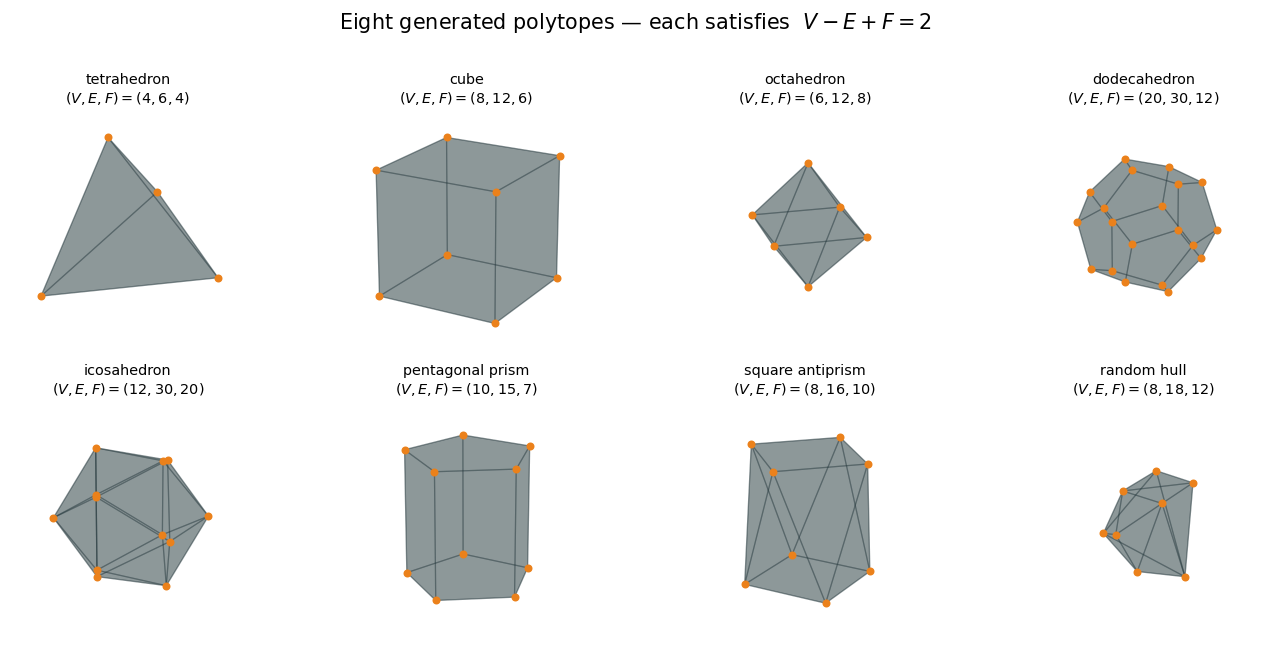

In [5]:
gallery = [("tetrahedron", tetra()), ("cube", cube()), ("octahedron", octa()),
           ("dodecahedron", dodeca()), ("icosahedron", icosa()),
           ("pentagonal prism", prism(5)), ("square antiprism", antiprism(4)),
           ("random hull", np.random.randn(11, 3))]

fig = plt.figure(figsize=(12, 5.6))
for i, (title, pts) in enumerate(gallery):
    ax = fig.add_subplot(2, 4, i+1, projection="3d")
    faces, V, E, F = poly_faces(pts)
    ax.add_collection3d(Poly3DCollection(faces, alpha=0.30, facecolor=TEAL,
                                         edgecolor=TEAL, linewidths=0.8))
    hv = ConvexHull(pts).vertices
    ax.scatter(*pts[hv].T, color=ORANGE, s=16, depthshade=False)
    ax.set_title(f"{title}\n$(V,E,F)=({V},{E},{F})$", fontsize=9)
    ax.set_box_aspect((1,1,1)); ax.set_axis_off()
    r = np.abs(pts).max()*1.05
    ax.set_xlim(-r,r); ax.set_ylim(-r,r); ax.set_zlim(-r,r)
    ax.view_init(elev=20, azim=30)
plt.suptitle("Eight generated polytopes — each satisfies  $V-E+F=2$", y=1.0, fontsize=13)
plt.tight_layout(); plt.show()

### The data lives on a single plane

Plot every polytope as a point $(V,E,F)\in\mathbb{R}^3$, coloured by family. Although the shapes look wildly
different, **all of the points lie on one flat plane** — the plane $F = E - V + 2$. That plane *is* Euler's
formula, and it is the thing a linear model can capture.

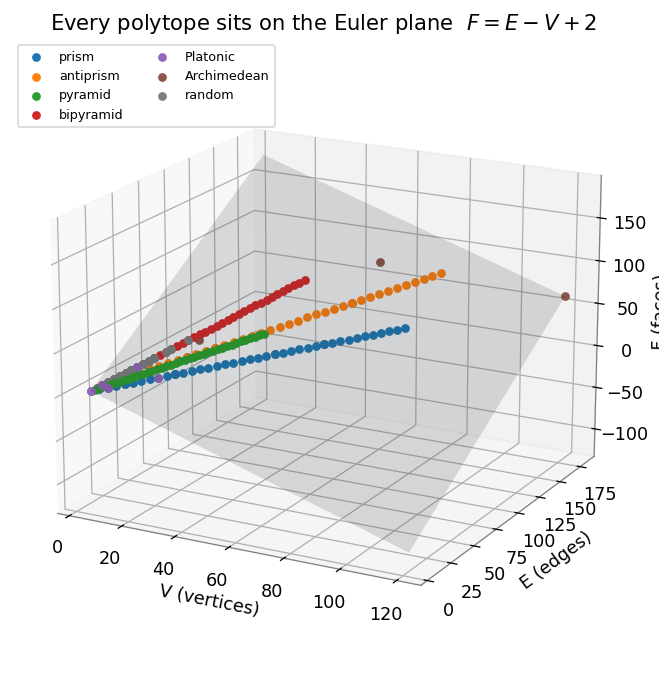

In [6]:
V, E, F = VEF[:,0], VEF[:,1], VEF[:,2]
fig = plt.figure(figsize=(7.6, 6))
ax = fig.add_subplot(111, projection="3d")
for fam in FAMILY_COLORS:
    m = families == fam
    if m.any():
        ax.scatter(V[m], E[m], F[m], s=20, color=FAMILY_COLORS[fam], label=fam, depthshade=False)
vv, ee = np.meshgrid(np.linspace(V.min(), V.max(), 8), np.linspace(E.min(), E.max(), 8))
ax.plot_surface(vv, ee, ee - vv + 2, alpha=0.15, color=TEAL)
ax.set_xlabel("V (vertices)"); ax.set_ylabel("E (edges)"); ax.set_zlabel("F (faces)")
ax.set_title("Every polytope sits on the Euler plane  $F = E - V + 2$")
ax.legend(loc="upper left", fontsize=8, ncol=2); ax.view_init(elev=18, azim=-62)
plt.tight_layout(); plt.show()

The **face-number statistics** of our "dataset" — the geometer's analogue of "how many of each digit are
in MNIST". The dataset spans a wide range of sizes, which is what lets the network pin down the relation
rather than overfit a few examples.

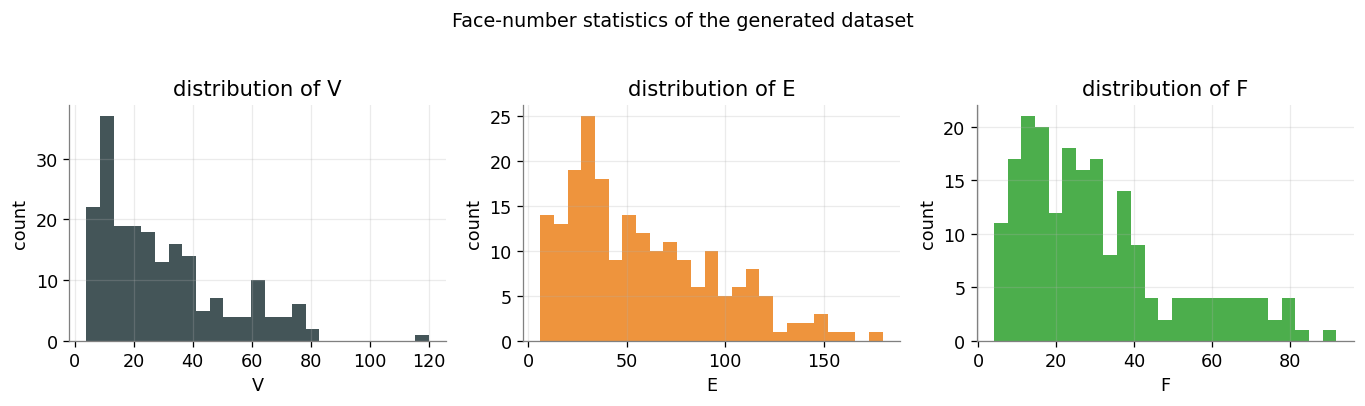

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, arr, name, col in zip(axes, [V, E, F], ["V", "E", "F"], [TEAL, ORANGE, "#2ca02c"]):
    ax.hist(arr, bins=25, color=col, alpha=0.85)
    ax.set_xlabel(name); ax.set_ylabel("count"); ax.set_title(f"distribution of {name}")
plt.suptitle("Face-number statistics of the generated dataset", y=1.03, fontsize=12)
plt.tight_layout(); plt.show()

### Why $(V,E)\mapsto F$ is well-posed

Each parametric family traces its **own straight line** in the $(V,E)$ plane (prisms have $E=\tfrac32 V$,
antiprisms $E=2V$, and so on). Because several different lines are present — plus the scattered random
hulls — the inputs $(V,E)$ genuinely fill a 2-D region. That is exactly what a single neuron needs to fix
the plane uniquely.

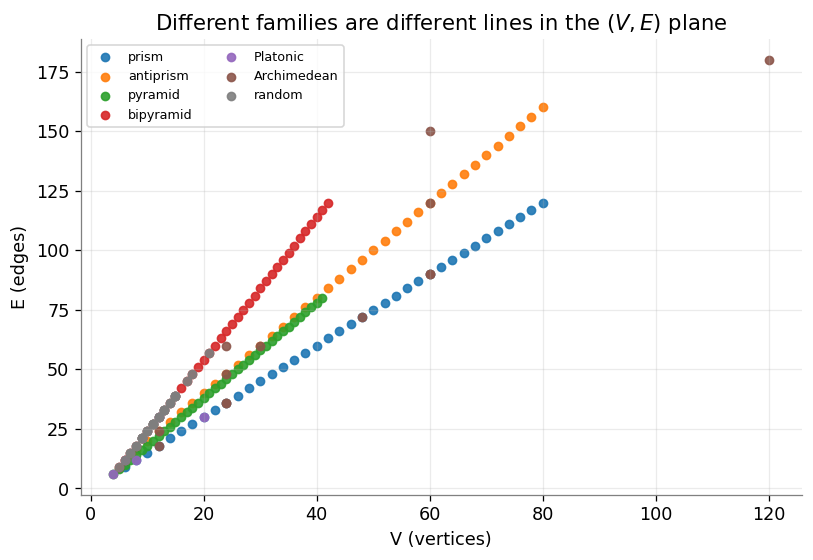

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 5))
for fam in FAMILY_COLORS:
    m = families == fam
    if m.any():
        ax.scatter(V[m], E[m], s=26, color=FAMILY_COLORS[fam], label=fam, alpha=0.9)
ax.set_xlabel("V (vertices)"); ax.set_ylabel("E (edges)")
ax.set_title("Different families are different lines in the $(V,E)$ plane")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

## 2. The learning task

We hand the network **only** the pair $(V,E)$ and ask it to predict $F$, scored by mean-squared error
$$\mathcal{L}(\theta)=\frac{1}{N}\sum_{k}\big(f_\theta(V_k,E_k)-F_k\big)^2 .$$

The model is a **single linear neuron**, $f_\theta(V,E)=w_V\,V + w_E\,E + b$ — deliberately the simplest
object that can exist, precisely because its two weights and bias are directly readable. *If it learns, the
weights **are** the theorem.*

To test whether it truly learns the **law** (rather than memorising), we **hold out the famous solids** —
the Platonic and Archimedean polytopes — as a test set the network never trains on.

In [18]:
is_famous = np.isin(families, ["Platonic", "Archimedean"])
Xtr = torch.tensor(VEF[~is_famous, :2], dtype=torch.float32)   # train inputs (V, E)
ytr = torch.tensor(VEF[~is_famous, 2:], dtype=torch.float32)   # train target F
Xte = torch.tensor(VEF[is_famous,  :2], dtype=torch.float32)   # held-out famous solids
yte = torch.tensor(VEF[is_famous,  2:], dtype=torch.float32)
print(f"training on {len(Xtr)} polytopes (prisms, antiprisms, pyramids, bipyramids, random hulls)")
print(f"testing  on {len(Xte)} famous solids the network never sees (Platonic + Archimedean)")

training on 187 polytopes (prisms, antiprisms, pyramids, bipyramids, random hulls)
testing  on 18 famous solids the network never sees (Platonic + Archimedean)


## 3. Training — watching it discover Euler

We record the two weights and the bias at **every epoch**, so we can literally watch the neuron travel from
its random initial guess to Euler's coefficients $(-1, +1, 2)$.

In [27]:
model = torch.nn.Linear(2, 1)                         # F ~ w_V*V + w_E*E + b
opt   = torch.optim.Adam(model.parameters(), lr=0.05)
EPOCHS = 4000

# IMPORTANT: clone/copy the initial values
w0 = model.weight.detach().clone().numpy().ravel()
b0 = model.bias.detach().clone().item()

w_hist = [[w0[0], w0[1], b0]]
loss_hist = []

for epoch in range(EPOCHS):
    opt.zero_grad()

    loss = ((model(Xtr) - ytr)**2).mean()

    loss.backward()
    opt.step()

    w = model.weight.detach().numpy().ravel()
    b = model.bias.item()

    w_hist.append([w[0], w[1], b])
    loss_hist.append(loss.item())

w_hist = np.array(w_hist)

wV, wE, bias = w_hist[-1]

print(f"start : w_V={w0[0]:+.4f}, w_E={w0[1]:+.4f}, b={b0:+.4f}   (random initialisation)")
print(f"end   : w_V={wV:+.4f}, w_E={wE:+.4f}, b={bias:+.4f}")
print(f"Euler : w_V=-1,      w_E=+1,      b=+2")
print(f"final MSE loss: {loss_hist[-1]:.2e}")

start : w_V=+0.3427, w_E=+0.0372, b=-0.3625   (random initialisation)
end   : w_V=-1.0000, w_E=+1.0000, b=+2.0000
Euler : w_V=-1,      w_E=+1,      b=+2
final MSE loss: 1.70e-14


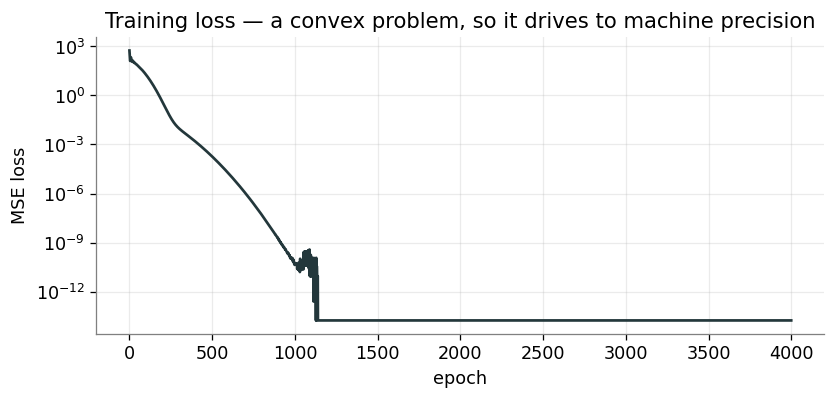

In [28]:
fig, ax = plt.subplots(figsize=(7.4, 3.6))
ax.plot(loss_hist, color=TEAL, lw=1.7)
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("MSE loss")
ax.set_title("Training loss — a convex problem, so it drives to machine precision")
plt.tight_layout(); plt.show()

**The discovery, as a trajectory.** Each weight starts near zero and slides onto its Euler value; the
dashed lines mark the targets $(-1, +1, 2)$.

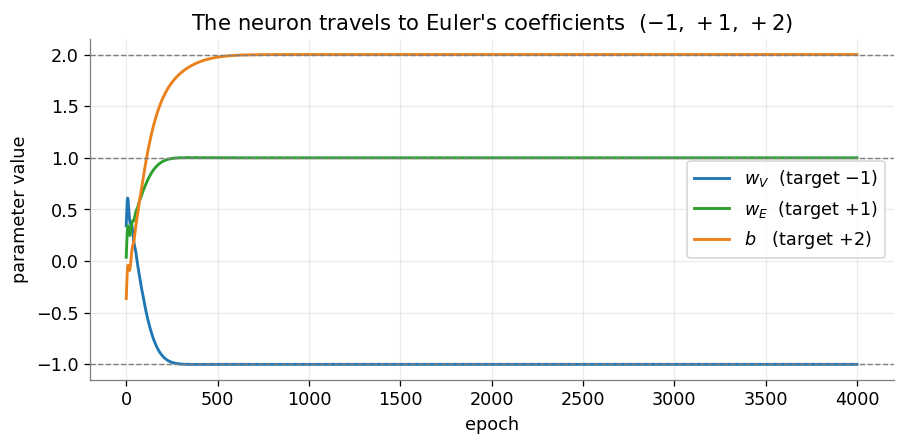

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(w_hist[:,0], color="#1f77b4", lw=1.8, label=r"$w_V$  (target $-1$)")
ax.plot(w_hist[:,1], color="#2ca02c", lw=1.8, label=r"$w_E$  (target $+1$)")
ax.plot(w_hist[:,2], color=ORANGE,    lw=1.8, label=r"$b$   (target $+2$)")
for tgt in (-1, 1, 2): ax.axhline(tgt, color=GREY, lw=0.9, ls="--")
ax.set_xlabel("epoch"); ax.set_ylabel("parameter value")
ax.set_title("The neuron travels to Euler's coefficients  $(-1,\\,+1,\\,+2)$")
ax.legend(loc="center right"); plt.tight_layout(); plt.show()

The same journey in the **weight plane** $(w_V, w_E)$: from the random start (grey) to the Euler
corner $(-1, +1)$ (star).

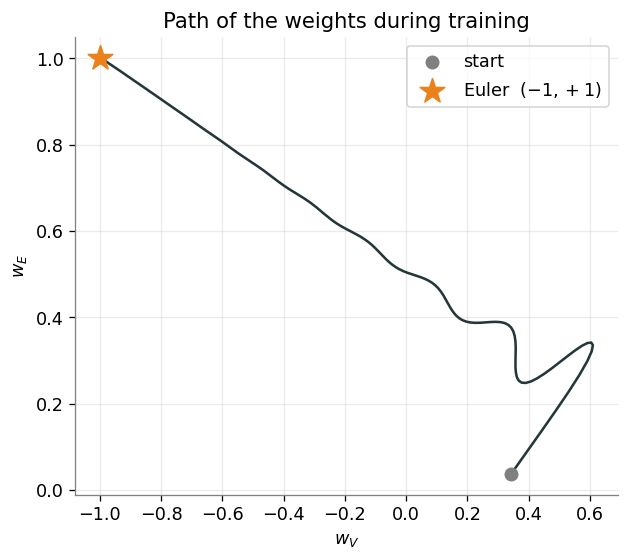

In [30]:
fig, ax = plt.subplots(figsize=(5.6, 5))
ax.plot(w_hist[:,0], w_hist[:,1], color=TEAL, lw=1.6)
ax.scatter([w_hist[0,0]], [w_hist[0,1]], color=GREY, s=60, zorder=5, label="start")
ax.scatter([-1], [1], marker="*", color=ORANGE, s=260, zorder=5, label="Euler  $(-1,+1)$")
ax.set_xlabel(r"$w_V$"); ax.set_ylabel(r"$w_E$")
ax.set_title("Path of the weights during training"); ax.legend()
plt.tight_layout(); plt.show()

**The plane tilting into place.** The neuron *is* a plane $F=w_V V + w_E E + b$ over the $(V,E)$ data.
Here it is at four moments in training — flat at initialisation, then rotating until it lands exactly on the
Euler plane.

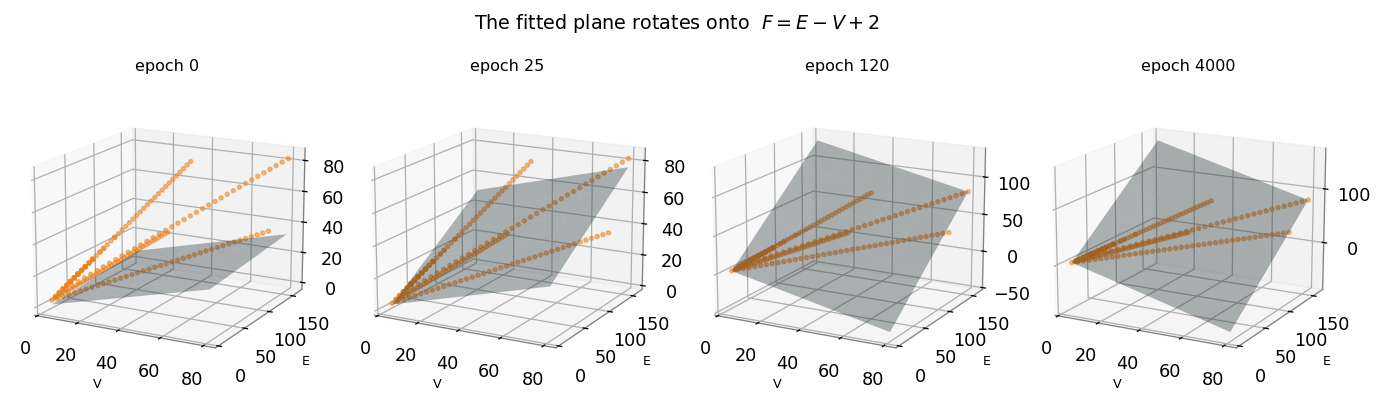

In [31]:
snap_epochs = [0, 25, 120, len(w_hist)-1]
data_tr = VEF[~is_famous]
fig = plt.figure(figsize=(12, 3.4))
for i, ep in enumerate(snap_epochs):
    ax = fig.add_subplot(1, 4, i+1, projection="3d")
    w = w_hist[ep]
    ax.scatter(data_tr[:,0], data_tr[:,1], data_tr[:,2], s=6, color=ORANGE, alpha=0.5)
    vv, ee = np.meshgrid(np.linspace(data_tr[:,0].min(), data_tr[:,0].max(), 6),
                         np.linspace(data_tr[:,1].min(), data_tr[:,1].max(), 6))
    ax.plot_surface(vv, ee, w[0]*vv + w[1]*ee + w[2], alpha=0.35, color=TEAL)
    ax.set_title(f"epoch {ep}", fontsize=10)
    ax.set_xlabel("V", fontsize=8); ax.set_ylabel("E", fontsize=8); ax.set_zlabel("F", fontsize=8)
    ax.view_init(elev=16, azim=-62)
plt.suptitle("The fitted plane rotates onto  $F = E - V + 2$", y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

## 4. What did it learn — and does it generalise?

Now the verification step. We check the learned coefficients against Euler, and — crucially — evaluate on
the **famous solids the network never trained on**.

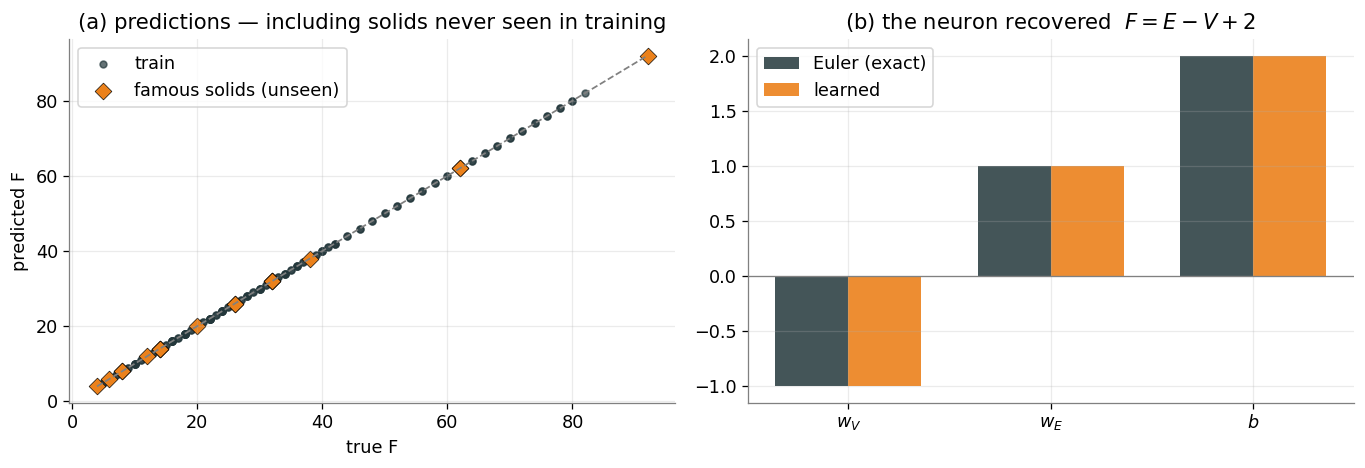

max error on the 18 unseen famous solids: 4.77e-07  (i.e. exact)


In [32]:
pred_tr = model(Xtr).detach().numpy().ravel()
pred_te = model(Xte).detach().numpy().ravel()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# (a) predicted vs true, train and held-out test
axes[0].scatter(ytr.numpy().ravel(), pred_tr, s=18, color=TEAL,   alpha=0.7, label="train")
axes[0].scatter(yte.numpy().ravel(), pred_te, s=55, color=ORANGE, marker="D",
                edgecolor="k", linewidths=0.4, label="famous solids (unseen)")
lo = min(ytr.min().item(), yte.min().item()); hi = max(ytr.max().item(), yte.max().item())
axes[0].plot([lo,hi],[lo,hi], color=GREY, lw=1.1, ls="--")
axes[0].set_xlabel("true F"); axes[0].set_ylabel("predicted F")
axes[0].set_title("(a) predictions — including solids never seen in training")
axes[0].legend()

# (b) learned vs true coefficients
labels = [r"$w_V$", r"$w_E$", r"$b$"]; learned = [wV, wE, bias]; true = [-1, 1, 2]
xpos = np.arange(3); width = 0.36
axes[1].bar(xpos-width/2, true,    width, label="Euler (exact)", color=TEAL,   alpha=0.85)
axes[1].bar(xpos+width/2, learned, width, label="learned",       color=ORANGE, alpha=0.9)
axes[1].axhline(0, color=GREY, lw=0.8); axes[1].set_xticks(xpos); axes[1].set_xticklabels(labels)
axes[1].set_title("(b) the neuron recovered  $F = E - V + 2$"); axes[1].legend()
plt.tight_layout(); plt.show()

err_te = np.abs(pred_te - yte.numpy().ravel())
print(f"max error on the {len(err_te)} unseen famous solids: {err_te.max():.2e}  (i.e. exact)")

**Residuals** on train and test — everything sits at machine-precision zero. The network did not
approximate a trend; it found the *exact integer law*.

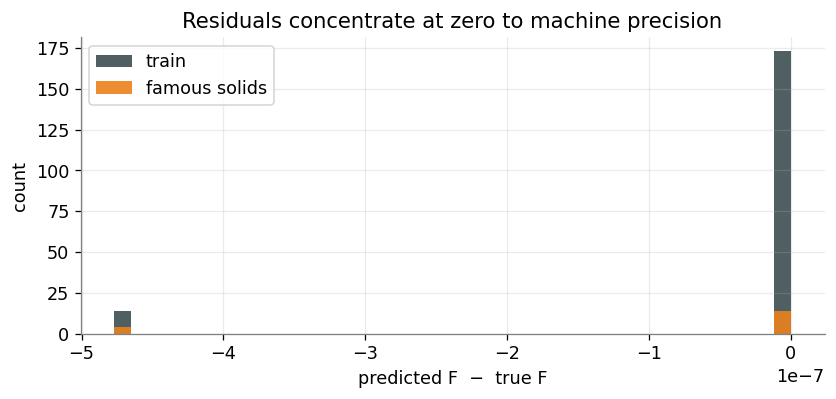

In [33]:
fig, ax = plt.subplots(figsize=(7.4, 3.6))
ax.hist(pred_tr - ytr.numpy().ravel(), bins=40, color=TEAL,   alpha=0.8, label="train")
ax.hist(pred_te - yte.numpy().ravel(), bins=40, color=ORANGE, alpha=0.9, label="famous solids")
ax.set_xlabel("predicted F  −  true F"); ax.set_ylabel("count")
ax.set_title("Residuals concentrate at zero to machine precision"); ax.legend()
plt.tight_layout(); plt.show()

**What just happened.** From nothing but $(V,E)$ pairs, a single neuron converged to
$w_V=-1,\ w_E=+1,\ b=+2$: it *rediscovered Euler's formula*. Because the data is noiseless we can check the
identity **exactly**, and because it learned the genuine law it predicts a dodecahedron or a soccer-ball
polyhedron it never saw. This is the whole template — **encode $\to$ loss $\to$ train $\to$ verify** — that
Part II applies to a Ricci-flat metric.

## 5. Scaling up — the general **Euler–Poincaré** relation

In dimension $d$ the face vector is $(f_0,\dots,f_{d-1})$ (for $d=3$ this is $(V,E,F)$) and the
Euler–Poincaré relation reads $\sum_i (-1)^i f_i = 1-(-1)^d$. For **4-polytopes** it becomes
$f_0-f_1+f_2-f_3=0$, i.e.
$$f_3 = f_0 - f_1 + f_2 .$$

We build many 4-polytopes as **prisms** ($P\times I$) and **pyramids** (cones) over our 3-polytopes — their
$f$-vectors follow by elementary formulas — and add the six **regular** 4-polytopes (the 4-simplex,
tesseract, 16-, 24-, 120- and 600-cell). Then one linear neuron $(f_0,f_1,f_2)\mapsto f_3$ recovers the
alternating coefficients $(+1,-1,+1)$.

In [36]:
r4 = []
for (Vv, Ee, Ff) in VEF:                                  # over every 3-polytope
    r4.append((2*Vv, 2*Ee+Vv, 2*Ff+Ee, Ff+2))             # prism  P x I
    r4.append((Vv+1, Ee+Vv, Ff+Ee, Ff+1))                 # pyramid (cone)
regular4 = [(5,10,10,5),(16,32,24,8),(8,24,32,16),(24,96,96,24),(120,720,1200,600),(600,1200,720,120)]
r4 += regular4
F4 = np.array(r4, dtype=float)
ep4 = F4[:,0] - F4[:,1] + F4[:,2] - F4[:,3]
print(f"{len(F4)} 4-polytopes;  f0-f1+f2-f3 in [{ep4.min():.3f}, {ep4.max():.3f}]  (want 0)")

C = F4.max()                                              # scale for well-conditioned GD
X4 = torch.tensor(F4[:, :3]/C, dtype=torch.float32)
y4 = torch.tensor(F4[:, 3:]/C, dtype=torch.float32)
m4 = torch.nn.Linear(3, 1); opt4 = torch.optim.Adam(m4.parameters(), lr=0.05)
for epoch in range(6000):
    opt4.zero_grad(); l4 = ((m4(X4) - y4)**2).mean(); l4.backward(); opt4.step()
w4 = m4.weight.detach().numpy().ravel(); b4 = m4.bias.item()*C
print(f"learned : f3 ~ {w4[0]:+.3f} f0 {w4[1]:+.3f} f1 {w4[2]:+.3f} f2  +  {b4:+.3f}")
print(f"Euler–Poincaré : f3 =  +1 f0   -1 f1   +1 f2  +  0")

416 4-polytopes;  f0-f1+f2-f3 in [0.000, 0.000]  (want 0)
learned : f3 ~ +1.000 f0 -1.000 f1 +1.000 f2  +  +0.000
Euler–Poincaré : f3 =  +1 f0   -1 f1   +1 f2  +  0


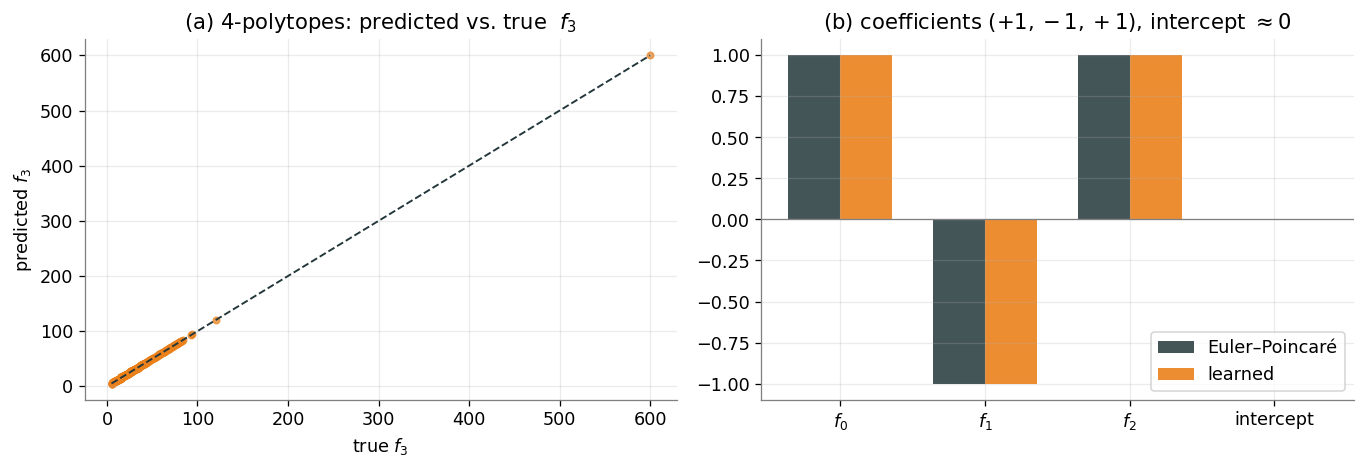

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
pred4 = (m4(X4).detach().numpy().ravel())*C
axes[0].scatter(F4[:,3], pred4, color=ORANGE, s=16, alpha=0.7)
lo, hi = F4[:,3].min(), F4[:,3].max()
axes[0].plot([lo,hi],[lo,hi], color=TEAL, lw=1.2, ls="--")
axes[0].set_xlabel(r"true $f_3$"); axes[0].set_ylabel(r"predicted $f_3$")
axes[0].set_title("(a) 4-polytopes: predicted vs. true  $f_3$")

labels = [r"$f_0$", r"$f_1$", r"$f_2$", "intercept"]
xpos = np.arange(4); width = 0.36
axes[1].bar(xpos-width/2, [1,-1,1,0],               width, label="Euler–Poincaré", color=TEAL,   alpha=0.85)
axes[1].bar(xpos+width/2, [w4[0],w4[1],w4[2],b4],   width, label="learned",         color=ORANGE, alpha=0.9)
axes[1].axhline(0, color=GREY, lw=0.8); axes[1].set_xticks(xpos); axes[1].set_xticklabels(labels)
axes[1].set_title(r"(b) coefficients $(+1,-1,+1)$, intercept $\approx 0$"); axes[1].legend()
plt.tight_layout(); plt.show()

## 6. From a toy to a research tool

You just watched a neuron **rediscover** two theorems — Euler ($V-E+F=2$) and its higher-dimensional cousin
Euler–Poincaré — from raw face vectors, with the weights landing *exactly* on the known coefficients.

The reason this matters: the very same setup works **where no formula is known**. Reflexive
(**Kreuzer–Skarke**) polytopes are in one-to-one correspondence with Calabi–Yau 3-folds, and one can train
networks to predict their **Hodge numbers** and other invariants directly from the polytope data — turning
machine learning into a device for *conjecturing* new structure. That is the doorway to **Part II**, where
the object of study is no longer a face count but a **Ricci-flat metric**, and the "loss" is a geometric PDE
rather than a label.

> **The recipe, once more:**  **encode** the geometry as vectors  →  **choose** a loss  →  **train**  →
> **verify** against something you can check. Everything else in this workshop is a variation on it.